# Todo
- Explore the bid-ask spread across different maturities and strikes
- Explore the bid-ask spread across different underlying assets
- Explore the spread wrt to vega, implied volatility, etc.
- Explore the spread for a single day
- See the impact of transaction cost on backtest result
  - Try implementing another tcost model
- Backtest delta hedging strategies
- Backtest delta-gamma hedging strategies
  - Try other variant on calls or puts.

In [1]:
# Setup auto reload
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc("font", **{"size": 18})
import numpy as np
from warnings import filterwarnings
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

filterwarnings("ignore")

import investment_lab.option_selection as option_selection
import investment_lab.backtest as backtest
from investment_lab.data.option_db import OptionLoader
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.option_trade import OptionTrade, DeltaHedgedOptionTrade, DeltaGammaHedgedOptionTrade
from investment_lab.backtest import StrategyBacktester, BacktesterBidAskFromData, BacktesterFixedRelativeBidAsk

from investment_lab.pricing.black_scholes import black_scholes_price, black_scholes_greeks
from investment_lab.rates import compute_forward
from investment_lab import option_strategies as option_strategies

In [3]:
df_options = OptionLoader.load_data(datetime(2020, 1, 4), datetime(2022, 12, 4), process_kwargs={"ticker": "SPY"})
df_options.head()

2026-02-06 09:18:10,523 | INFO | Reading between 2020-01-04 00:00:00 2022-12-04 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-06 09:18:51,234 | INFO | Processing with {'ticker': 'SPY'}
2026-02-06 09:18:51,237 | INFO | Potentially add extra field with None


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
5867,323.68,265.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,58.68,58.68,0.0,C,SPY 20200106C265,58.68,SPY,2020-01-06,0,0.818710
5868,323.68,270.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,53.68,53.68,0.0,C,SPY 20200106C270,53.68,SPY,2020-01-06,0,0.834157
5869,323.68,275.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,48.68,48.68,0.0,C,SPY 20200106C275,48.68,SPY,2020-01-06,0,0.849605
5870,323.68,280.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,43.68,43.68,41.0,C,SPY 20200106C280,43.68,SPY,2020-01-06,0,0.865052
5871,323.68,285.0,2020-01-06,1.0,0.0,0.0,0.0,0.0,0.0,38.68,38.68,1.0,C,SPY 20200106C285,38.68,SPY,2020-01-06,0,0.880499


In [4]:
df_options["ask_bid_spread"] = df_options["ask"] - df_options["bid"]
df_options["ask_bid_spread_perc"] = (df_options["ask"] - df_options["bid"]) / df_options["mid"]

In [ ]:
ax = (df_options.groupby("date")["ask_bid_spread"].median()+(df_options.groupby("date")["ask_bid_spread"].std())).plot(label="+1 std",color="orange",legend=True)
df_options.groupby("date")["ask_bid_spread"].median().plot(grid=True, figsize=(20,8),title='Median Daily bid-ask spread | SPY',ylabel="Absolute Bid-Ask Spread ($)",label="Median",ax=ax,color="blue",legend=True)

# df_options.groupby("date")["ask_bid_spread_perc"].mean().plot( figsize=(20,8),ax=ax.twinx(),ylabel="Relative Bid-Ask Spread (%)",color='orange')


In [5]:
df_options["day_to_expiration_bucket"] = pd.cut(
    df_options["day_to_expiration"],
    bins=[0, 7, 30, 90, 180, 360, 720, 1080],
    labels=["0-7", "8-30", "31-90", "91-180", "181-360", "361-720", "721-1080"],
)

df_options["delta_bucket"] = pd.cut(
    df_options["delta"],
    bins=[-1.0, -0.9, -0.75, -0.5, -0.25, 0, 0.1, 0.25, 0.5, 0.75, 0.9, 1],
    labels=[
        "[-1; -0.9]",
        "[-0.9; -0.75]",
        "[-0.75; -0.5]",
        "[-0.5; -0.25]",
        "[-0.25; 0]",
        "[0; 0.1]",
        "[0.1; 0.25]",
        "[0.25; 0.5]",
        "[0.5; 0.75]",
        "[0.75; 0.9]",
        "[0.9; 1]",
    ],
)


df_options["moneyness_bucket"] = pd.cut(
    df_options["moneyness"],
    bins=[0.5, 0.75, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.25, 1.5],
    labels=[
        "[0.50; 0.75]",
        "[0.75; 0.85]",
        "[0.85; 0.90]",
        "[0.90; 0.95]",
        "[0.95; 1.00]",
        "[1.00; 1.05]",
        "[1.05; 1.10]",
        "[1.10; 1.25]",
        "[1.25; 1.50]",
    ],
)

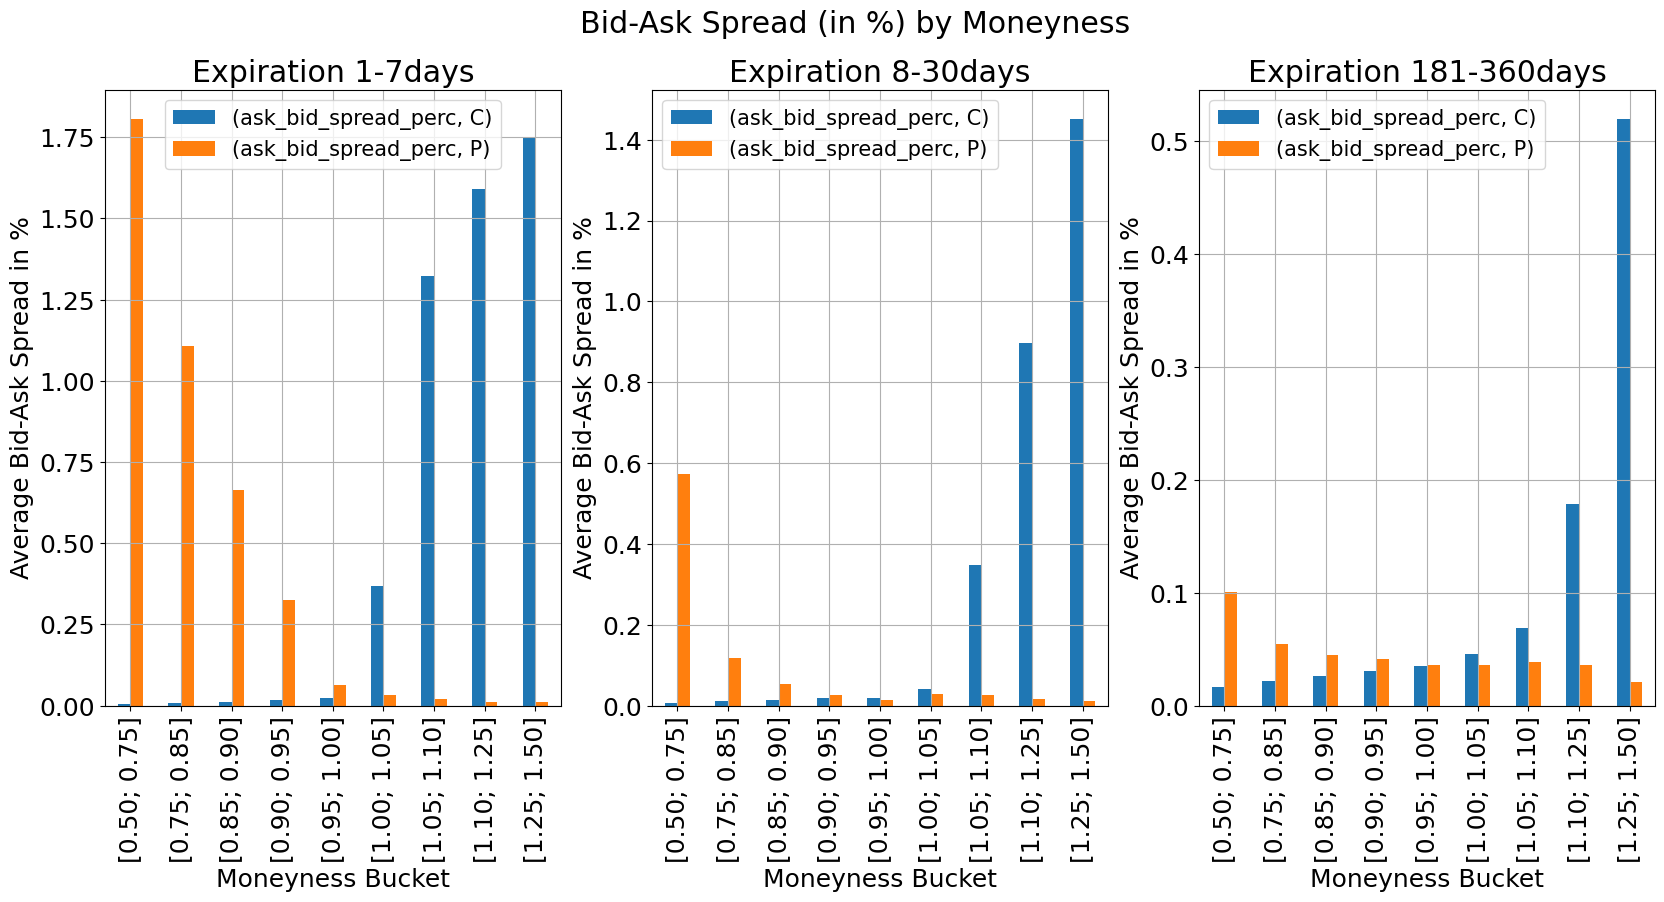

In [6]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Bid-Ask Spread (in %) by Moneyness")
df_options[df_options["day_to_expiration_bucket"] == "0-7"].groupby(["moneyness_bucket", "call_put"])[["ask_bid_spread_perc"]].mean().unstack().plot.bar(
    xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 1-7days", ax=ax
)
ax.legend(fontsize=15)

df_options[df_options["day_to_expiration_bucket"] == "8-30"].groupby(["moneyness_bucket", "call_put"])[["ask_bid_spread_perc"]].mean().unstack().plot.bar(
    xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 8-30days", ax=ax2
)
ax2.legend(fontsize=15)


df_options[df_options["day_to_expiration_bucket"] == "181-360"].groupby(["moneyness_bucket", "call_put"])[
    ["ask_bid_spread_perc"]
].mean().unstack().plot.bar(xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 181-360days", ax=ax3)
ax3.legend(fontsize=15)

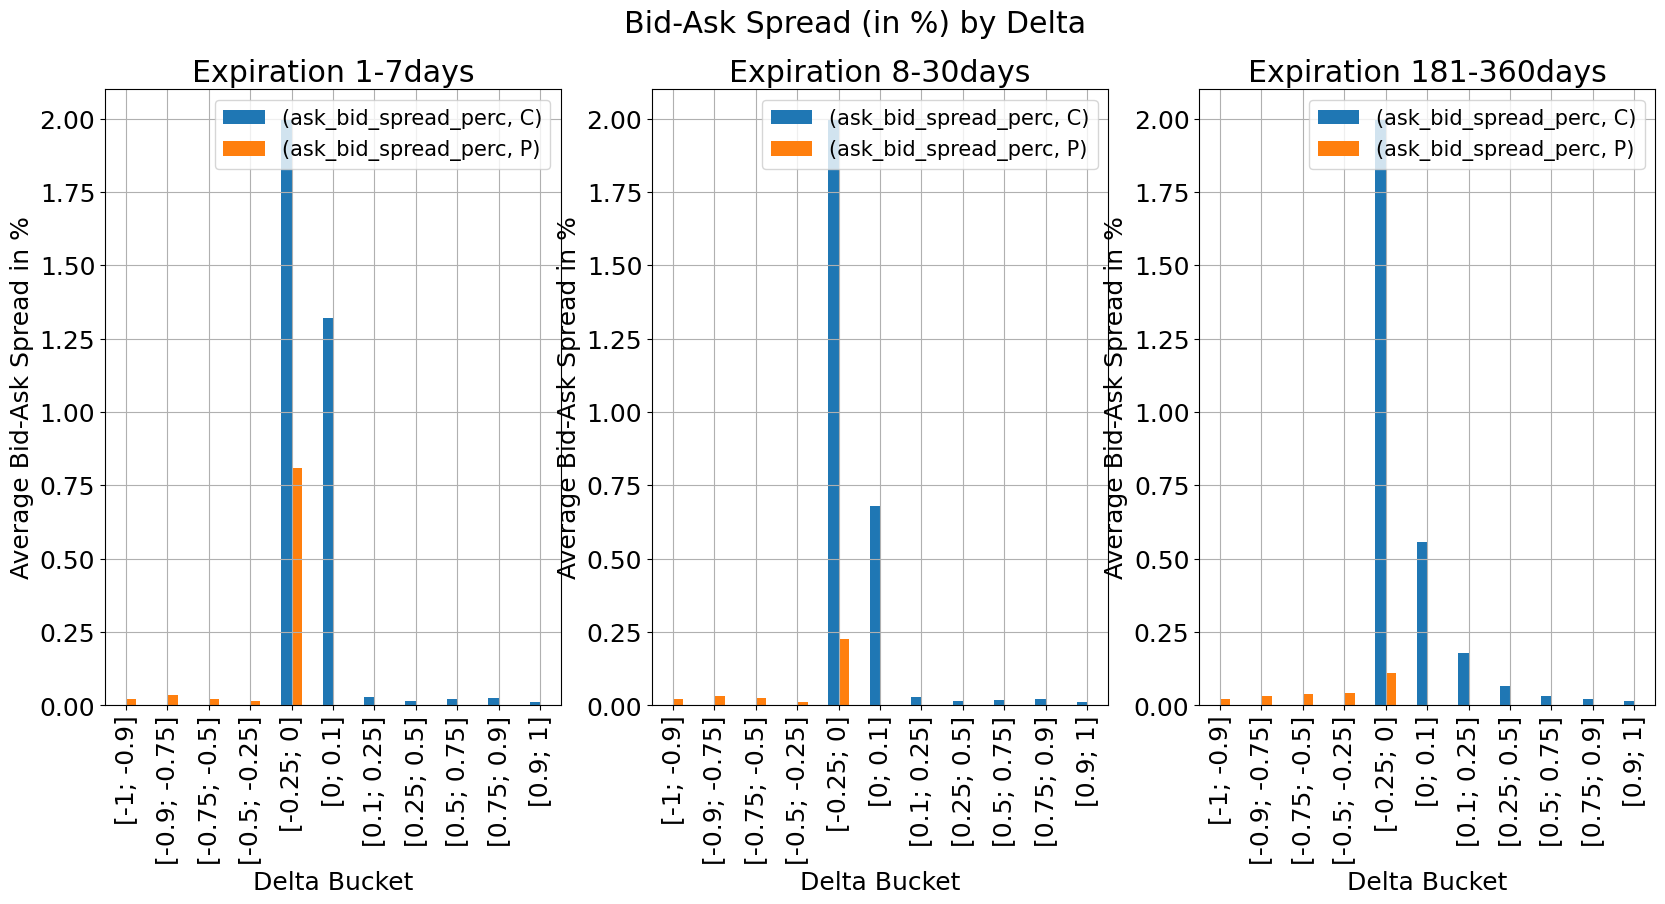

In [7]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Bid-Ask Spread (in %) by Delta")
df_options[df_options["day_to_expiration_bucket"] == "0-7"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread_perc"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 1-7days", ax=ax
)
ax.legend(fontsize=15)

df_options[df_options["day_to_expiration_bucket"] == "8-30"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread_perc"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 8-30days", ax=ax2
)
ax2.legend(fontsize=15)


df_options[df_options["day_to_expiration_bucket"] == "181-360"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread_perc"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in %", grid=True, title="Expiration 181-360days", ax=ax3
)
ax3.legend(fontsize=15)

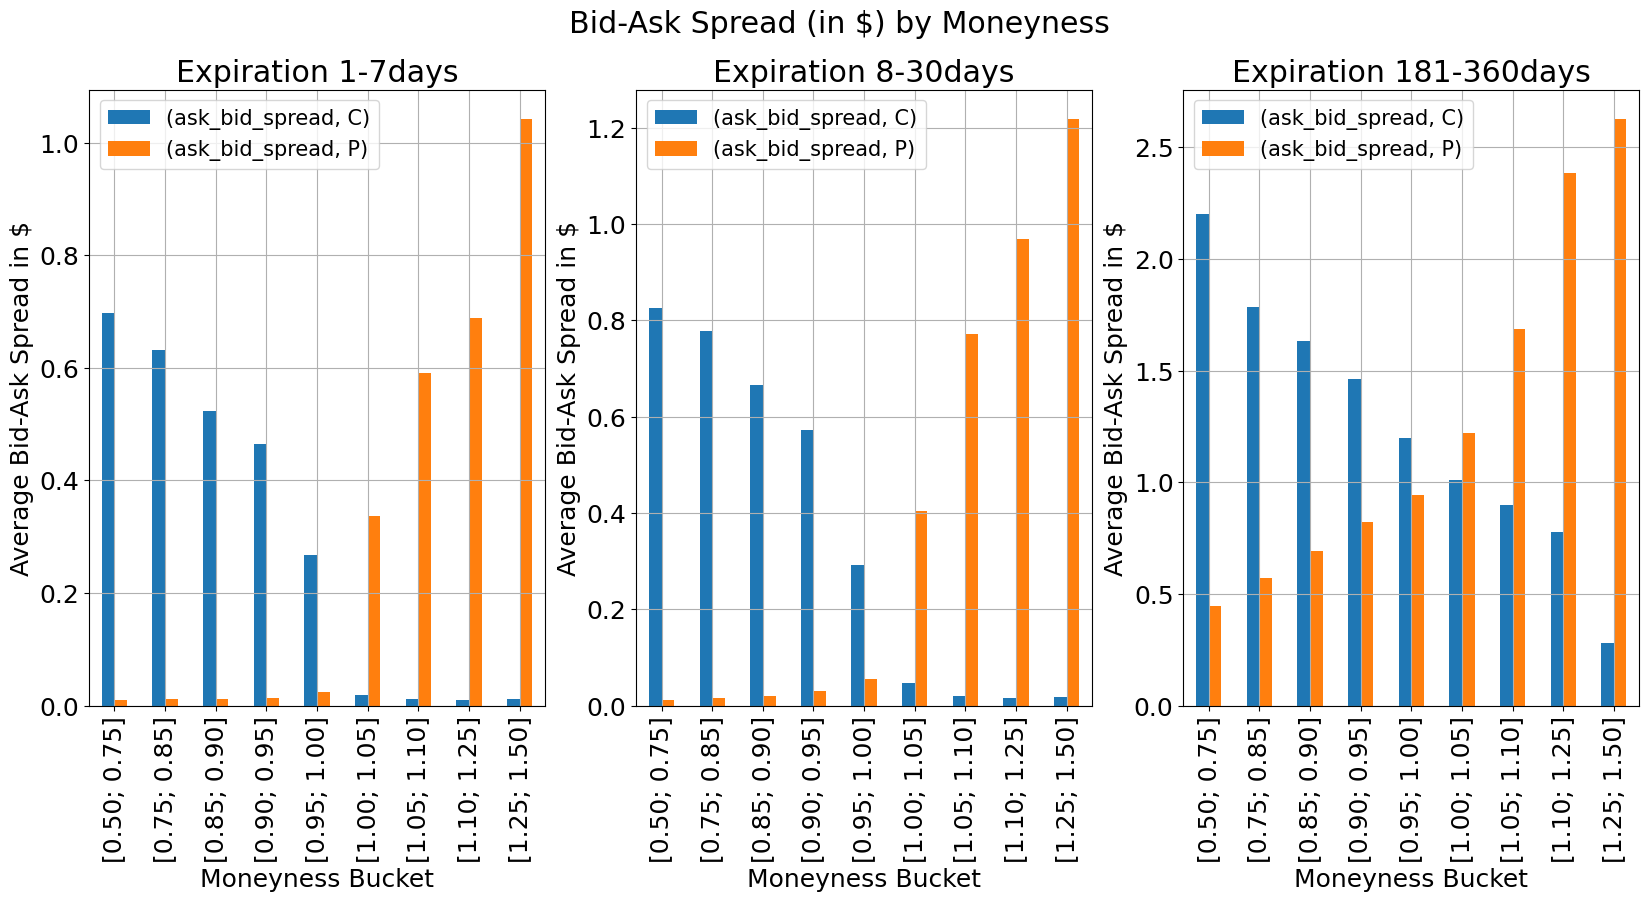

In [8]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Bid-Ask Spread (in $) by Moneyness")
df_options[df_options["day_to_expiration_bucket"] == "0-7"].groupby(["moneyness_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 1-7days", ax=ax
)
ax.legend(fontsize=15)

df_options[df_options["day_to_expiration_bucket"] == "8-30"].groupby(["moneyness_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 8-30days", ax=ax2
)
ax2.legend(fontsize=15)


df_options[df_options["day_to_expiration_bucket"] == "181-360"].groupby(["moneyness_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Moneyness Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 181-360days", ax=ax3
)
ax3.legend(fontsize=15)

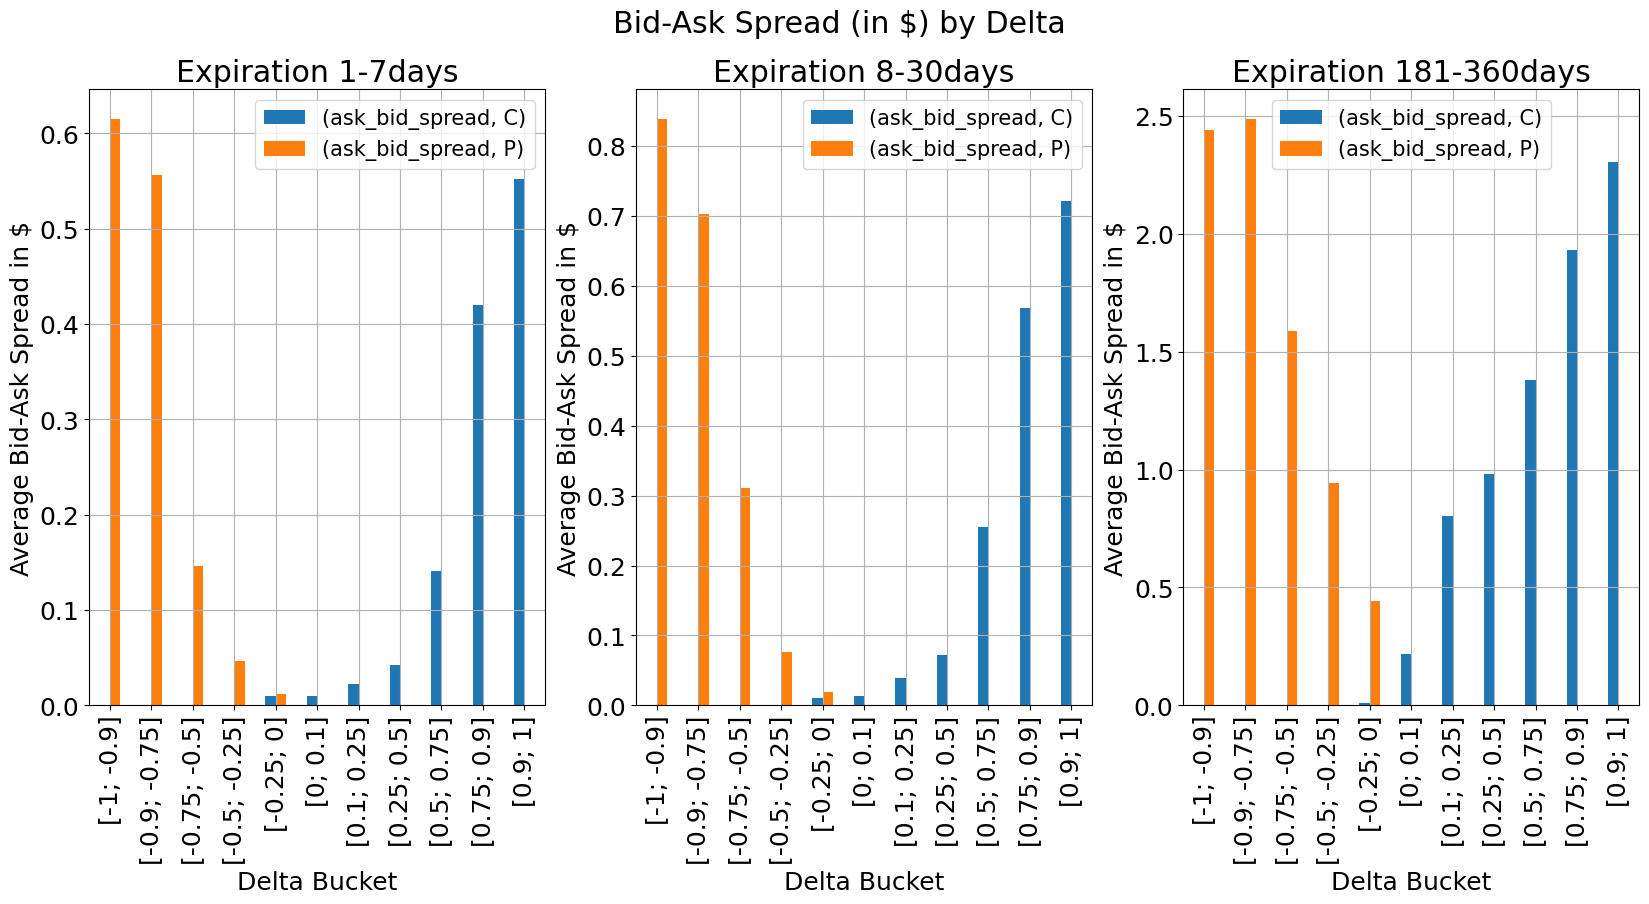

In [9]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Bid-Ask Spread (in $) by Delta")
df_options[df_options["day_to_expiration_bucket"] == "0-7"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 1-7days", ax=ax
)
ax.legend(fontsize=15)

df_options[df_options["day_to_expiration_bucket"] == "8-30"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 8-30days", ax=ax2
)
ax2.legend(fontsize=15)


df_options[df_options["day_to_expiration_bucket"] == "181-360"].groupby(["delta_bucket", "call_put"])[["ask_bid_spread"]].mean().unstack().plot.bar(
    xlabel="Delta Bucket", ylabel="Average Bid-Ask Spread in $", grid=True, title="Expiration 181-360days", ax=ax3
)
ax3.legend(fontsize=15)

# Bid Ask Spread: P&L Impact


In [6]:
df_SHORT_1W_STRANGLE_95_105 = OptionTrade.generate_trades(
    datetime(2020, 1, 2),
    datetime(2022, 12, 30),
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

2026-02-07 15:50:04,735 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-02-07 15:50:04,735 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-07 15:50:42,760 | INFO | Processing with {'ticker': 'SPY'}
2026-02-07 15:50:42,760 | INFO | Potentially add extra field with None
2026-02-07 15:50:57,194 | INFO | Preprocessing option data.
2026-02-07 15:50:57,238 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-02-07 15:51:00,827 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-02-07 15:51:03,587 | INFO | Converting 898 df_trades to daily time series
2026-02-07 15:51:15,995 | INFO | Forward filling option data for df_trades
2026-02-07 15:51:

In [19]:
backtest_SHORT_1W_STRANGLE_95_105 = StrategyBacktester(df_SHORT_1W_STRANGLE_95_105).compute_backtest()
backtest_SHORT_1W_STRANGLE_95_105

2026-02-07 16:24:21,091 | INFO | Reading between 2020-01-08 00:00:00 2023-01-04 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-07 16:24:30,196 | INFO | Processing with {'ticker': ['SPY']}
2026-02-07 16:24:30,210 | INFO | Potentially add extra field with None
2026-02-07 16:24:45,239 | INFO | Forward filling option data for df
2026-02-07 16:24:46,376 | INFO | Deleting StrategyBacktest instance and freeing up memory.
2026-02-07 16:24:46,626 | INFO | Reading between 2020-01-08 00:00:00 2023-01-04 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-02-07 16:24:46,672 | INFO | Processing with None
2026-02-07 16:24:46,674 | INFO | Potentially add extra field with None
2026-02-07 16:24:51,419 | INFO | No transaction cost applied here.
2026-02-07 16:24:51,427 | INFO | Computing period to period difference, for P&L calculations.
2026-02-07 16:24:51,427 | INFO | Append previous period greeks for P&L calculations.
2026-02-07 16:24:51,515 | INFO | Starting

<Axes: >

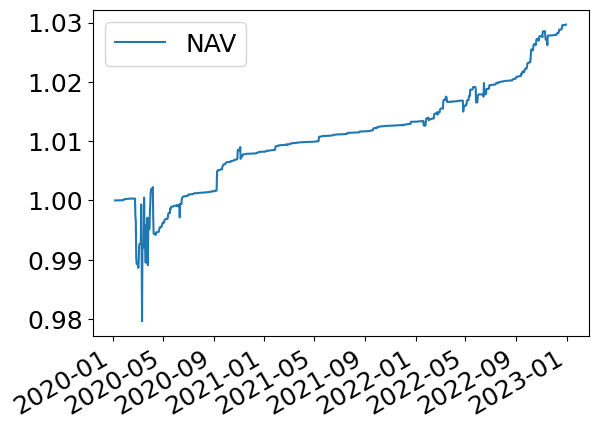

In [20]:
backtest_SHORT_1W_STRANGLE_95_105.nav.plot()

In [21]:
backtest_SHORT_1W_STRANGLE_95_105 = StrategyBacktester(df_SHORT_1W_STRANGLE_95_105).compute_backtest()
backtest_SHORT_1W_STRANGLE_95_105_datatcost = BacktesterBidAskFromData(df_SHORT_1W_STRANGLE_95_105).compute_backtest()
backtest_SHORT_1W_STRANGLE_95_105_03tcost = BacktesterFixedRelativeBidAsk(df_SHORT_1W_STRANGLE_95_105).compute_backtest(
    tcost_args={"relative_half_spread": 0.03}
)

2026-02-07 16:25:53,867 | INFO | Reading between 2020-01-08 00:00:00 2023-01-04 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-07 16:26:04,412 | INFO | Processing with {'ticker': ['SPY']}
2026-02-07 16:26:04,422 | INFO | Potentially add extra field with None
2026-02-07 16:26:23,845 | INFO | Forward filling option data for df
2026-02-07 16:26:25,300 | INFO | Reading between 2020-01-08 00:00:00 2023-01-04 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-02-07 16:26:25,450 | INFO | Processing with None
2026-02-07 16:26:25,451 | INFO | Potentially add extra field with None
2026-02-07 16:26:32,860 | INFO | No transaction cost applied here.
2026-02-07 16:26:32,872 | INFO | Computing period to period difference, for P&L calculations.
2026-02-07 16:26:32,886 | INFO | Append previous period greeks for P&L calculations.
2026-02-07 16:26:32,968 | INFO | Starting backtest computation over 753 unique dates.
100%|██████████| 753/753 [00:12<00:00, 59.27it

In [23]:
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio

In [24]:
pd.DataFrame(
    [
        {
            "Name": name,
            "Maximum Drawdown": max_drawdown(nav["NAV"].pct_change().dropna())*100,
            "Sharpe Ratio": sharpe_ratio(nav["NAV"].pct_change().dropna()),
            "Calmar Ratio": calmar_ratio(nav["NAV"].pct_change().dropna()),
        }
        for name, nav in {
            "SHORT_1W_STRANGLE_95_105": backtest_SHORT_1W_STRANGLE_95_105.nav,
            "SHORT_1W_STRANGLE_95_105_data_tcost": backtest_SHORT_1W_STRANGLE_95_105_datatcost.nav,
            "SHORT_1W_STRANGLE_95_105_fixed_03tcost": backtest_SHORT_1W_STRANGLE_95_105_03tcost.nav,
        }.items()
    ]
)

,Name,Maximum Drawdown,Sharpe Ratio,Calmar Ratio
0,SHORT_1W_STRANGLE_95_105,-2.069583,0.578979,0.479648
1,SHORT_1W_STRANGLE_95_105_data_tcost,-2.069583,0.578979,0.479648
2,SHORT_1W_STRANGLE_95_105_fixed_03tcost,-2.151401,0.505502,0.406190


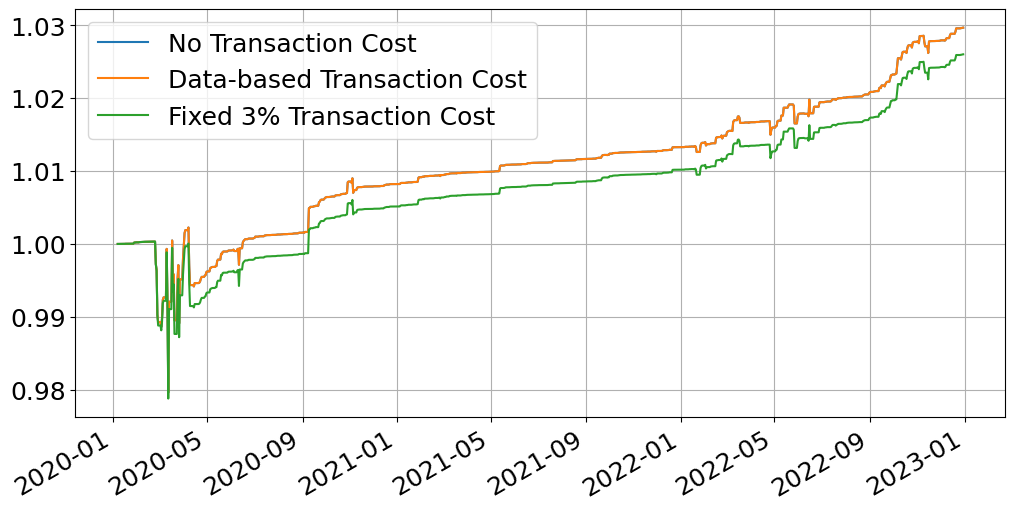

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

backtest_SHORT_1W_STRANGLE_95_105.nav["NAV"].plot(ax=ax, label="No Transaction Cost")
backtest_SHORT_1W_STRANGLE_95_105_datatcost.nav["NAV"].plot(ax=ax, label="Data-based Transaction Cost")
backtest_SHORT_1W_STRANGLE_95_105_03tcost.nav["NAV"].plot(ax=ax, label="Fixed 3% Transaction Cost")
ax.legend()
ax.grid()

In [18]:
df_SHORT_1W_STRANGLE_95_105["ask_bid_spread"] = df_SHORT_1W_STRANGLE_95_105["ask"] - df_SHORT_1W_STRANGLE_95_105["bid"]
df_SHORT_1W_STRANGLE_95_105["ask_bid_spread_perc"] = (df_SHORT_1W_STRANGLE_95_105["ask"] - df_SHORT_1W_STRANGLE_95_105["bid"]) / df_SHORT_1W_STRANGLE_95_105["mid"]
df_SHORT_1W_STRANGLE_95_105

,date,option_id,entry_date,leg_name,weight,ticker,spot,strike,expiration,delta,...,volume,call_put,mid,day_to_expiration,moneyness,criterion,risk_free_rate,forward,ask_bid_spread,ask_bid_spread_perc
0,2020-01-03,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY,322.43,339.0,2020-01-10,0.00263,...,9.0,C,0.000,7.0,1.051391,0.0,0.0152,322.523940,0.00,NaN
1,2020-01-03,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY,322.43,306.0,2020-01-10,-0.02730,...,60.0,P,0.095,7.0,0.949043,0.0,0.0152,322.523940,0.01,0.105263
2,2020-01-06,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY,323.68,339.0,2020-01-10,0.00282,...,0.0,C,0.005,4.0,1.047331,3.0,0.0154,323.734594,0.01,2.000000
3,2020-01-06,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY,323.68,306.0,2020-01-10,-0.00930,...,181.0,P,0.025,4.0,0.945378,3.0,0.0154,323.734594,0.01,0.400000
4,2020-01-06,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY,323.68,340.0,2020-01-13,0.00261,...,0.0,C,0.005,7.0,1.050420,0.0,0.0154,323.775545,0.01,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5385,2022-12-30,SPY 20230103P364,2022-12-26,Short K=95% Put 1W,-0.000435,SPY,382.44,364.0,2023-01-03,-0.00948,...,657.0,P,0.025,4.0,0.951783,3.0,0.0412,382.612595,0.01,0.400000
5386,2022-12-30,SPY 20230104C396,2022-12-28,Short K=105% Call 1W,-0.000442,SPY,382.44,396.0,2023-01-04,0.01625,...,394.0,C,0.035,5.0,1.035457,2.0,0.0412,382.655756,0.01,0.285714
5387,2022-12-30,SPY 20230104P358,2022-12-28,Short K=95% Put 1W,-0.000442,SPY,382.44,358.0,2023-01-04,-0.00920,...,9.0,P,0.035,5.0,0.936095,2.0,0.0412,382.655756,0.01,0.285714
5388,2022-12-30,SPY 20230106C402,2022-12-30,Short K=105% Call 1W,-0.000436,SPY,382.44,402.0,2023-01-06,0.01700,...,687.0,C,0.055,7.0,1.051145,0.0,0.0412,382.742092,0.01,0.181818


# Hedging


## Delta Hedging


In [14]:
df_SHORT_1W_STRANGLE_95_105 = OptionTrade.generate_trades(
    datetime(2020, 1, 2),
    datetime(2021, 4, 30),
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

2026-02-07 19:47:05,074 | INFO | Loading option data from 2020-01-02 00:00:00 to 2021-04-30 00:00:00
2026-02-07 19:47:05,076 | INFO | Reading between 2020-01-02 00:00:00 2021-04-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-07 19:47:16,684 | INFO | Processing with {'ticker': 'SPY'}
2026-02-07 19:47:16,686 | INFO | Potentially add extra field with None
2026-02-07 19:47:22,882 | INFO | Preprocessing option data.
2026-02-07 19:47:22,884 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-02-07 19:47:24,110 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-02-07 19:47:25,164 | INFO | Converting 392 df_trades to daily time series
2026-02-07 19:47:26,961 | INFO | Forward filling option data for df
2026-02-07 19:47:27,371 

In [15]:
df_SHORT_1W_STRANGLE_95_105_DH = DeltaHedgedOptionTrade.generate_trades(
    datetime(2020, 1, 2),
    datetime(2021, 4, 30),
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

2026-02-07 19:47:31,330 | INFO | Loading option data from 2020-01-02 00:00:00 to 2021-04-30 00:00:00
2026-02-07 19:47:31,359 | INFO | Reading between 2020-01-02 00:00:00 2021-04-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-07 19:47:44,327 | INFO | Processing with {'ticker': 'SPY'}
2026-02-07 19:47:44,335 | INFO | Potentially add extra field with None
2026-02-07 19:47:50,510 | INFO | Preprocessing option data.
2026-02-07 19:47:50,513 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-02-07 19:47:52,198 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-02-07 19:47:53,917 | INFO | Converting 392 df_trades to daily time series
2026-02-07 19:47:56,773 | INFO | Forward filling option data for df
2026-02-07 19:47:57,371 

In [18]:
backtest_SHORT_1W_STRANGLE_95_105 = StrategyBacktester(df_SHORT_1W_STRANGLE_95_105).compute_backtest()
backtest_SHORT_1W_STRANGLE_95_105_DH = StrategyBacktester(df_SHORT_1W_STRANGLE_95_105_DH).compute_backtest()
# backtest_SHORT_1W_STRANGLE_95_105_DH_tcost = BacktesterFixedRelativeBidAsk(df_SHORT_1W_STRANGLE_95_105_DH).compute_backtest(tcost_args={"relative_half_spread": 0.03})


2026-02-07 19:53:17,212 | INFO | Shifting +1 business to ensure valid trading result.
2026-02-07 19:53:17,259 | INFO | Reading between 2020-01-06 00:00:00 2021-05-03 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


2026-02-07 19:53:25,990 | INFO | Processing with {'ticker': ['SPY']}
2026-02-07 19:53:25,998 | INFO | Potentially add extra field with None
2026-02-07 19:53:34,404 | INFO | Forward filling option data for df
2026-02-07 19:53:34,629 | INFO | Deleting StrategyBacktest instance and freeing up memory.
2026-02-07 19:53:35,088 | INFO | No transaction cost applied here.
2026-02-07 19:53:35,092 | INFO | Computing period to period difference, for P&L calculations.
2026-02-07 19:53:35,101 | INFO | Append previous period greeks for P&L calculations.
2026-02-07 19:53:35,134 | INFO | Starting backtest computation over 346 unique dates.
  0%|          | 0/346 [00:00<?, ?it/s]


KeyError: "Columns not found: 'rho_pnl'"

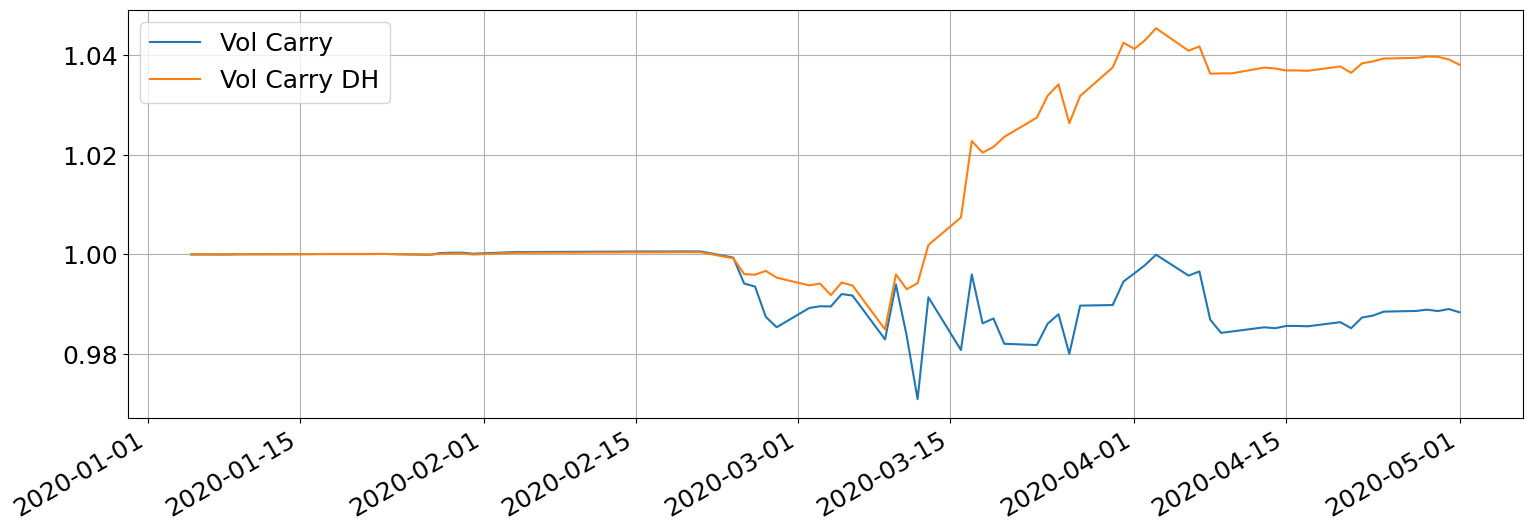

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(18, 6))
backtest_SHORT_1W_STRANGLE_95_105.nav["NAV"].plot(ax=ax, label="Vol Carry")
backtest_SHORT_1W_STRANGLE_95_105_DH.nav["NAV"].plot(ax=ax, label="Vol Carry DH")
# backtest_SHORT_1W_STRANGLE_95_105_DH_tcost.nav["NAV"].plot(ax=ax, label="Vol Carry DH (3% tcost)")
ax.legend()
ax.grid()

<Axes: title={'center': 'Vol Carry DH'}>

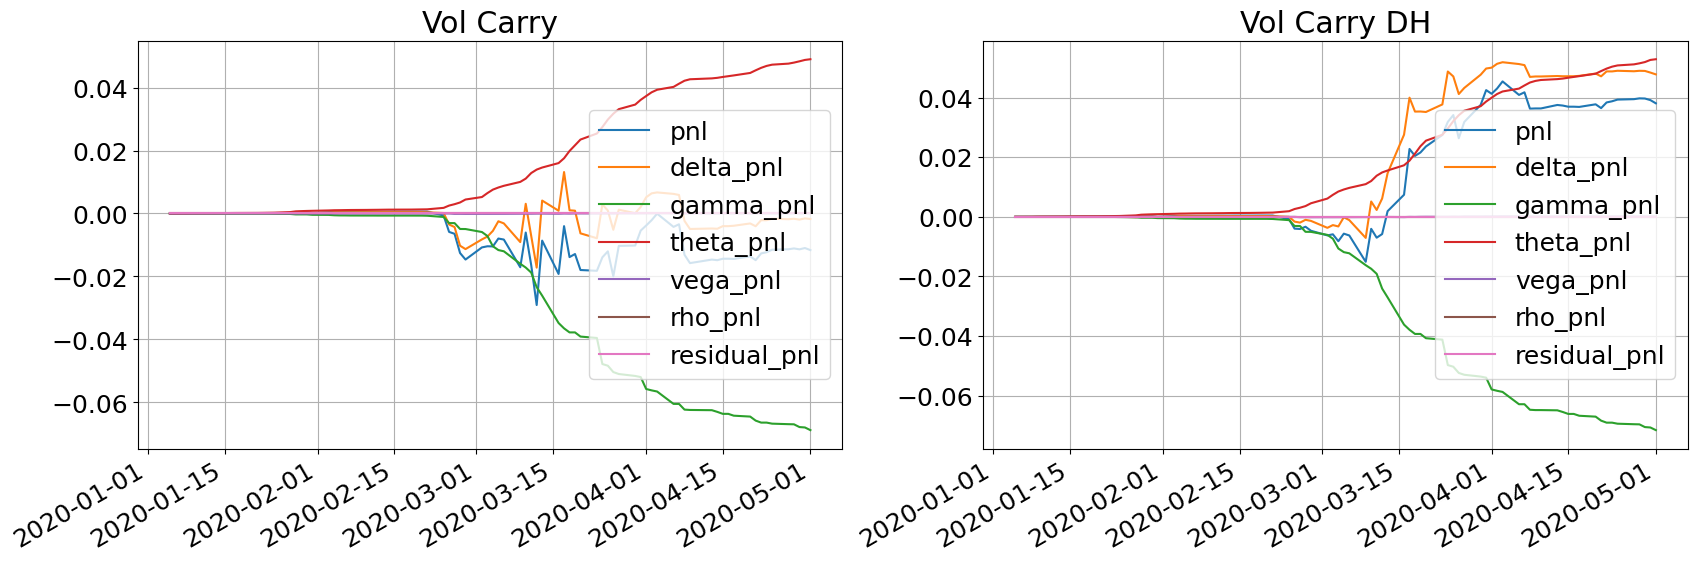

In [ ]:
fig, (ax,ax2) = plt.subplots(1, 2, figsize=(20, 6))

backtest_SHORT_1W_STRANGLE_95_105.pnl.cumsum().plot(ax=ax, title="Vol Carry",grid=True)
backtest_SHORT_1W_STRANGLE_95_105_DH.pnl.cumsum().plot(ax=ax2, title="Vol Carry DH",grid=True)


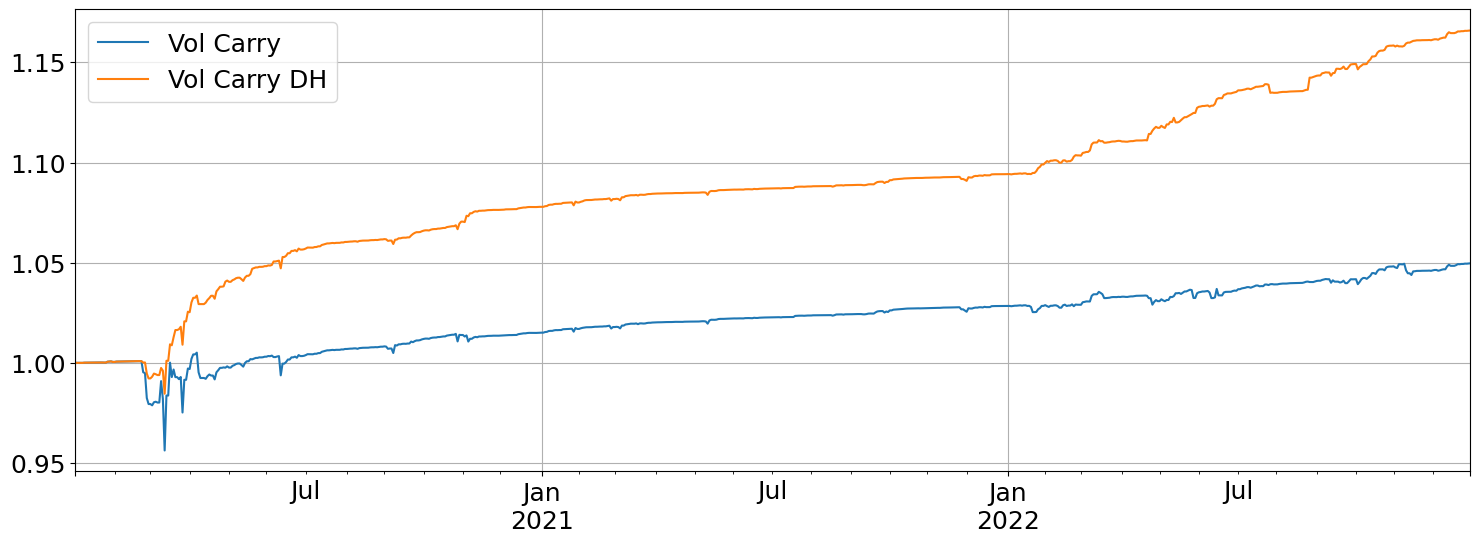

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

backtest_SHORT_1W_STRANGLE_95_105.nav["NAV"].plot(ax=ax, label="Vol Carry")
backtest_SHORT_1W_STRANGLE_95_105_DH.nav["NAV"].plot(ax=ax, label="Vol Carry DH")
ax.legend()
ax.grid()

In [60]:
pd.DataFrame(
    [
        {
            "Name": name,
            "Maximum Drawdown": max_drawdown(nav["NAV"].pct_change().dropna())*100,
            "Sharpe Ratio": sharpe_ratio(nav["NAV"].pct_change().dropna()),
            "Calmar Ratio": calmar_ratio(nav["NAV"].pct_change().dropna()),
        }
        for name, nav in {
            "SHORT_1W_STRANGLE_95_105": backtest_SHORT_1W_STRANGLE_95_105.nav,
            "SHORT_1W_STRANGLE_95_105_DH": backtest_SHORT_1W_STRANGLE_95_105_DH.nav,
            "SHORT_1W_STRANGLE_95_105_DGH": backtest_SHORT_1W_STRANGLE_95_105_DGH.nav,
        }.items()
    ]
)

,Name,Maximum Drawdown,Sharpe Ratio,Calmar Ratio
0,SHORT_1W_STRANGLE_95_105,-4.455640,0.485525,0.363684
1,SHORT_1W_STRANGLE_95_105_DH,-1.625284,2.633146,3.058996
2,SHORT_1W_STRANGLE_95_105_DGH,-0.981542,3.181355,5.290117


<Axes: xlabel='date'>

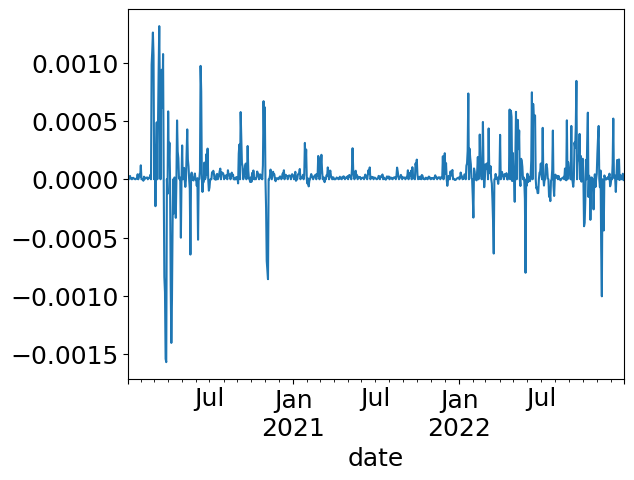

In [41]:
df = backtest_SHORT_1W_STRANGLE_95_105.drifted_positions.copy()
df['wgt_delta'] = df['delta']*df['scaled_weight']
df.groupby(["date"])['wgt_delta'].sum().plot()

<Axes: xlabel='date'>

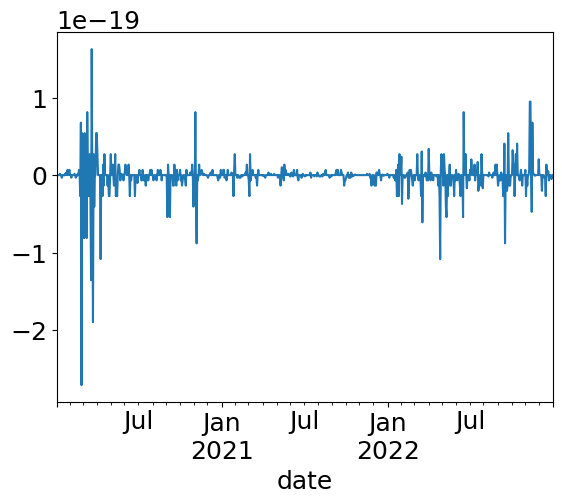

In [40]:
df_dh = backtest_SHORT_1W_STRANGLE_95_105_DH.drifted_positions.copy()
df_dh['wgt_delta'] = df_dh['delta']*df_dh['scaled_weight']
df_dh.groupby(["date"])['wgt_delta'].sum().plot()

## Delta-Gamma Hedging

Good hedging leg:

```python
"hedging_leg":{
    "day_to_expiry_target": 5,
    "strike_target": -0.1,
    "strike_col": "delta",
    "call_or_put": "P",
    "weight": 0.2,
    "leg_name": "Long 5D Call 5d",
    "rebal_week_day": [2],
}
```


In [44]:
df_SHORT_1W_STRANGLE_95_105_DGH = DeltaGammaHedgedOptionTrade.generate_trades(
    datetime(2020, 1, 2),
    datetime(2022, 12, 30),
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
    hedging_args={
        "hedging_leg":{
            "day_to_expiry_target": 5,
            "strike_target": -0.1,
            "strike_col": "delta",
            "call_or_put": "P",
            "weight": 0.2,
            "leg_name": "Long 10D Put 5d",
            "rebal_week_day": [2],
        }
    }
)

2026-02-06 10:47:33,279 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-02-06 10:47:33,280 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-06 10:47:40,595 | INFO | Processing with {'ticker': 'SPY'}
2026-02-06 10:47:40,595 | INFO | Potentially add extra field with None
2026-02-06 10:47:46,627 | INFO | Preprocessing option data.
2026-02-06 10:47:46,631 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-02-06 10:47:48,997 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-02-06 10:47:50,877 | INFO | Converting 898 df_trades to daily time series
2026-02-06 10:47:55,845 | INFO | Forward filling option data for df_trades
2026-02-06 10:47:

In [50]:
df_SHORT_1W_STRANGLE_95_105_GH = DeltaHedgedOptionTrade.generate_trades(
    datetime(2020, 1, 2),
    datetime(2022, 12, 30),
    tickers="SPY",
    legs=[{
            "day_to_expiry_target": 5,
            "strike_target": -0.1,
            "strike_col": "delta",
            "call_or_put": "P",
            "weight": 0.2,
            "leg_name": "Long 10D Put 5d",
            "rebal_week_day": [2],
        }],
    cost_neutral=False,
)

2026-02-06 10:52:54,586 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-02-06 10:52:54,586 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-02-06 10:53:04,800 | INFO | Processing with {'ticker': 'SPY'}
2026-02-06 10:53:04,800 | INFO | Potentially add extra field with None
2026-02-06 10:53:13,387 | INFO | Preprocessing option data.
2026-02-06 10:53:13,402 | INFO | Selecting options for leg: Long 10D Put 5d using the rules:
{'day_to_expiry_target': 5, 'strike_target': -0.1, 'strike_col': 'delta', 'call_or_put': 'P'}
2026-02-06 10:53:16,725 | INFO | Converting 155 df_trades to daily time series
2026-02-06 10:53:23,798 | INFO | Forward filling option data for df_trades
2026-02-06 10:53:24,033 | INFO | Reading between 2020-01-08 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-02-06 10:53:24,071 | INFO | Processing with None
2026-02-06 10:53:

In [51]:
df_SHORT_1W_STRANGLE_95_105_GH = BacktesterBidAskFromData(df_SHORT_1W_STRANGLE_95_105_GH).compute_backtest()

2026-02-06 10:53:32,263 | INFO | Assigning bid ask spread from data on transaction dates.
2026-02-06 10:53:32,263 | INFO | Computing period to period difference, for P&L calculations.
2026-02-06 10:53:32,263 | INFO | Append previous period greeks for P&L calculations.
2026-02-06 10:53:32,296 | INFO | Starting backtest computation over 635 unique dates.
100%|██████████| 635/635 [00:08<00:00, 73.78it/s] 
2026-02-06 10:53:40,908 | INFO | Backtest computation completed.


<Axes: >

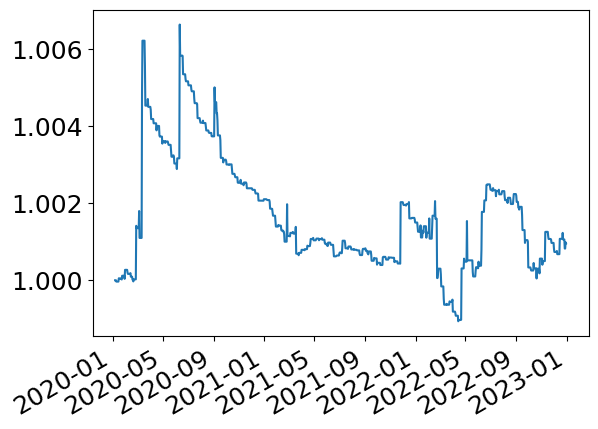

In [56]:
((backtest_SHORT_1W_STRANGLE_95_105_GH.pnl['pnl']-backtest_SHORT_1W_STRANGLE_95_105_GH.pnl['delta_pnl']).cumsum()+1).plot()

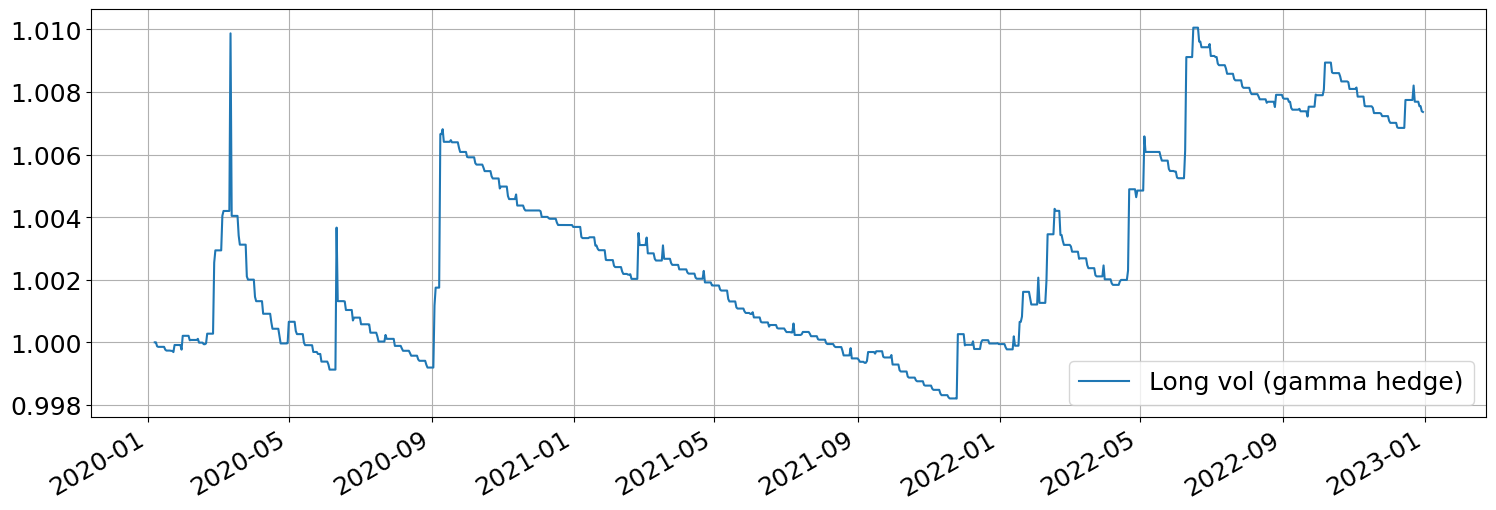

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(18, 6))
backtest_SHORT_1W_STRANGLE_95_105_GH.pnl
backtest_SHORT_1W_STRANGLE_95_105_GH.nav["NAV"].plot(ax=ax, label="Long vol (gamma hedge)")
ax.legend()
ax.grid()

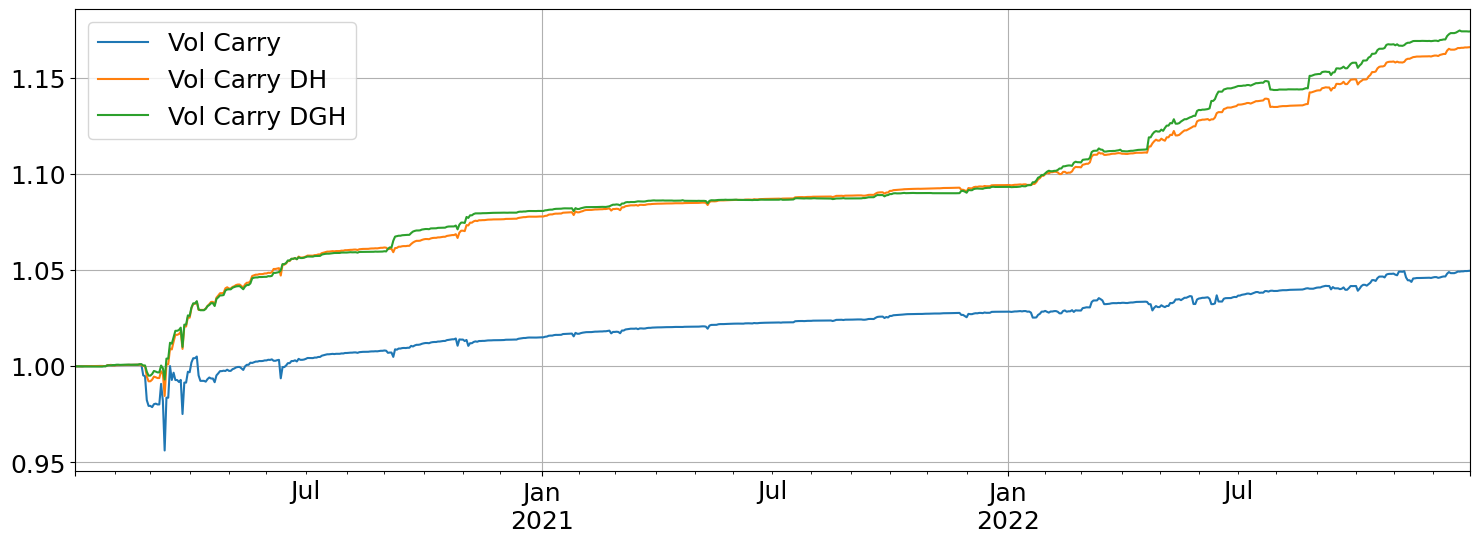

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

backtest_SHORT_1W_STRANGLE_95_105.nav["NAV"].plot(ax=ax, label="Vol Carry")
backtest_SHORT_1W_STRANGLE_95_105_DH.nav["NAV"].plot(ax=ax, label="Vol Carry DH")
backtest_SHORT_1W_STRANGLE_95_105_DGH.nav["NAV"].plot(ax=ax, label="Vol Carry DGH")
ax.legend()
ax.grid()